# Preprocessing, label construction, train/val/test split

*   Reads `data/raw_combined.h5ad`, performs QC + normalization + HVG selection
*   builds the `expanded` label per patient from the TCR
metadata
*   assigns each patient to train/val/test
* saves `data/processed.h5ad` for the modeling notebooks (notebooks #3 and #4)

## 1. Colab setup

In [ ]:
# colab setup
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
PROJECT_DIR_DRIVE = '/content/drive/MyDrive/final_project'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = PROJECT_DIR_DRIVE
    subprocess.run(['pip', 'install', '-q', 'scanpy', 'umap-learn'], check=True)
else:
    # for running locally, assume notebook lives in notebooks/, project root is one up
    PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'models'), exist_ok=True)
print('PROJECT_DIR =', PROJECT_DIR)
print('DATA_DIR    =', DATA_DIR)
print('RESULTS_DIR =', RESULTS_DIR)

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/final_project
DATA_DIR    = /content/drive/MyDrive/final_project/data
RESULTS_DIR = /content/drive/MyDrive/final_project/results


In [ ]:
import anndata as ad
from pathlib import Path
from src import data as D

adata = ad.read_h5ad(Path(DATA_DIR) / 'raw_combined.h5ad')
print(adata)
print(adata.obs.head())

AnnData object with n_obs × n_vars = 141623 × 30727
    obs: 'sample', 'UMAP_1', 'UMAP_2', 'ident', 'patient', 'source', 'clonotype'
    var: 'gene_id'
                       sample    UMAP_1    UMAP_2     ident patient source  \
LT1_AAACCTGAGGATATAC-1    LT1  0.761298  1.301195  8.3a-Trm   Lung1  Tumor   
LT1_AAACCTGAGTTACCCA-1    LT1 -6.475698  0.690571  4.3-TCF7   Lung1  Tumor   
LT1_AAACCTGCAACACCCG-1    LT1 -1.326519  0.730108   4.4-FOS   Lung1  Tumor   
LT1_AAACCTGCATCTCCCA-1    LT1 -3.510637  1.008227   4.4-FOS   Lung1  Tumor   
LT1_AAACCTGGTTCGTCTC-1    LT1 -5.588617  1.632665  4.3-TCF7   Lung1  Tumor   

                           clonotype  
LT1_AAACCTGAGGATATAC-1   lung1.tn.C1  
LT1_AAACCTGAGTTACCCA-1   lung1.tn.C3  
LT1_AAACCTGCAACACCCG-1   lung1.tn.C5  
LT1_AAACCTGCATCTCCCA-1   lung1.tn.C8  
LT1_AAACCTGGTTCGTCTC-1  lung1.tn.C12  


### Metadata columns
The T cell metadata file has these per-cell columns:
- `patient` (14 unique: Lung1..Lung4, Renal1..Renal3, Endo1..Endo3, Colon1..Colon4)
- `sample` (32 unique: LT1, LN1, LB1, ... where letter = tissue, digit = patient)
- `source` (Tumor / NAT / Blood)
- `ident` (16 cell-type clusters, e.g `8.3a-Trm`, `4.3-TCF7`)
- `clonotype` (55,260 unique TCR clonotypes, e.g `lung1.tn.C1`)
- `UMAP_1`, `UMAP_2` (UMAP coordinates from authors)

In [ ]:
CLONOTYPE_COL = 'clonotype'
PATIENT_COL = 'patient'

### Build the expansion label, then QC + normalize

In [ ]:
adata = D.build_expansion_label(adata, clonotype_col=CLONOTYPE_COL, patient_col=PATIENT_COL)
adata = D.qc_and_normalize(adata)
print(adata)

[label] dropping 45518 cells without a clonotype
[label] expanded fraction: 0.509 (48929 / 96105)
[qc] start: 96105 cells x 30727 genes
[qc] after filters: 95790 cells x 19815 genes
[hvg] kept 2000 highly variable genes
AnnData object with n_obs × n_vars = 95790 × 2000
    obs: 'sample', 'UMAP_1', 'UMAP_2', 'ident', 'patient', 'source', 'clonotype', 'clone_size', 'expanded', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


### Patient-stratified split (all cells from a patient go to one split)

In [ ]:
adata = D.patient_split(adata, patient_col=PATIENT_COL, val_frac=0.15, test_frac=0.2, seed=0)
adata.obs[['split', 'expanded']].value_counts()

[split] train=9 val=2 test=3 patients
[split] cells per split: {'train': 65435, 'test': 16131, 'val': 14224}


split  expanded
train  0           32931
       1           32504
val    1            8331
test   0            8217
       1            7914
val    0            5893
Name: count, dtype: int64

### Sanity plots: class balance per split & per patient

/tmp/ipykernel_5616/1887473175.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  split_bal = adata.obs.groupby('split')['expanded'].mean()
/tmp/ipykernel_5616/1887473175.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pat_bal = adata.obs.groupby(PATIENT_COL)['expanded'].mean().sort_values()


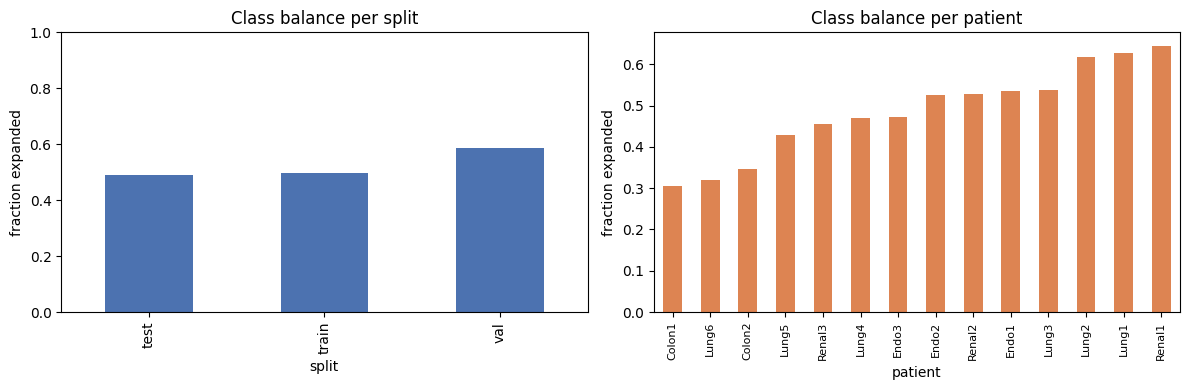

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

split_bal = adata.obs.groupby('split')['expanded'].mean()
split_bal.plot.bar(ax=axes[0], color='#4c72b0')
axes[0].set_ylabel('fraction expanded')
axes[0].set_title('Class balance per split')
axes[0].set_ylim(0, 1)

pat_bal = adata.obs.groupby(PATIENT_COL)['expanded'].mean().sort_values()
pat_bal.plot.bar(ax=axes[1], color='#dd8452')
axes[1].set_ylabel('fraction expanded')
axes[1].set_title('Class balance per patient')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)

fig.tight_layout()
fig.savefig(Path(RESULTS_DIR) / 'figures' / 'class_balance.png', dpi=150)

In [ ]:
out = Path(DATA_DIR) / 'processed.h5ad'
adata.write_h5ad(out, compression='gzip')
print('wrote', out, f'({out.stat().st_size/1e6:.1f} MB)')

wrote /content/drive/MyDrive/final_project/data/processed.h5ad (275.7 MB)
